# Question Difficulty Analysis with NLP and Machine Learning

**Author:** Ariton Verush  
**Academic context:** Individual higher-grade project for the Data Science course during the Bachelor's degree.

This notebook explores question-topic structure and binary question-difficulty classification using the CMU Question/Answer Dataset. The workflow includes data cleaning, exploratory analysis, TF-IDF vectorization, LDA topic modeling, K-means clustering, logistic regression, Universal Sentence Encoder embeddings, a Keras neural network, and XGBoost.

> **Reproducibility note:** Output cells are preserved from the original 2022 coursework run. Minor compatibility and path updates were applied for this public portfolio version; rerun values may vary because of library versions, random initialization, and external model downloads.


## Imports


In [1]:
from pathlib import Path
from random import Random
import string

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spacy
import tensorflow as tf
import tensorflow_hub as hub
from spacy.lang.en import English
from spacy.lang.en.stop_words import STOP_WORDS
from tensorflow import keras
from tqdm import tqdm
from wordcloud import WordCloud
from xgboost import XGBClassifier

from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

DATA_DIR = Path("data")


# Data preprocessing

## Load the data

In [2]:
df_08 = pd.read_csv(DATA_DIR / 's08_question_answer_pairs.tsv', sep='\t')


In [3]:
df_08.shape

(1715, 6)

In [4]:
df_08.head()

,ArticleTitle,Question,Answer,DifficultyFromQuestioner,DifficultyFromAnswerer,ArticleFile
0,Abraham_Lincoln,Was Abraham Lincoln the sixteenth President of...,yes,easy,easy,S08_set3_a4
1,Abraham_Lincoln,Was Abraham Lincoln the sixteenth President of...,Yes.,easy,easy,S08_set3_a4
2,Abraham_Lincoln,Did Lincoln sign the National Banking Act of 1...,yes,easy,medium,S08_set3_a4
3,Abraham_Lincoln,Did Lincoln sign the National Banking Act of 1...,Yes.,easy,easy,S08_set3_a4
4,Abraham_Lincoln,Did his mother die of pneumonia?,no,easy,medium,S08_set3_a4


In [5]:
df_09 = pd.read_csv(DATA_DIR / 's09_question_answer_pairs.tsv', sep='\t')


In [6]:
df_09.shape

(825, 6)

In [7]:
df_09.head()

,ArticleTitle,Question,Answer,DifficultyFromQuestioner,DifficultyFromAnswerer,ArticleFile
0,Alessandro_Volta,Was Volta an Italian physicist?,yes,easy,easy,S09_set4_a10
1,Alessandro_Volta,Was Volta an Italian physicist?,yes,easy,easy,S09_set4_a10
2,Alessandro_Volta,Is Volta buried in the city of Pittsburgh?,no,easy,easy,S09_set4_a10
3,Alessandro_Volta,Is Volta buried in the city of Pittsburgh?,no,easy,easy,S09_set4_a10
4,Alessandro_Volta,Did Volta have a passion for the study of elec...,yes,easy,medium,S09_set4_a10


In [8]:
df_10 = pd.read_csv(DATA_DIR / 's10_question_answer_pairs.tsv', sep='\t')


In [9]:
df_10.shape

(1458, 6)

In [10]:
df_10.head()

,ArticleTitle,Question,Answer,DifficultyFromQuestioner,DifficultyFromAnswerer,ArticleFile
0,Alessandro_Volta,Was Alessandro Volta a professor of chemistry?,Alessandro Volta was not a professor of chemis...,easy,easy,S10_set4_a10
1,Alessandro_Volta,Was Alessandro Volta a professor of chemistry?,No,easy,hard,S10_set4_a10
2,Alessandro_Volta,Did Alessandro Volta invent the remotely opera...,Alessandro Volta did invent the remotely opera...,easy,easy,S10_set4_a10
3,Alessandro_Volta,Did Alessandro Volta invent the remotely opera...,Yes,easy,easy,S10_set4_a10
4,Alessandro_Volta,Was Alessandro Volta taught in public schools?,Volta was taught in public schools.,easy,easy,S10_set4_a10


In [11]:
df = pd.concat([df_08, df_09, df_10], ignore_index=True)


In [12]:
df.shape

(3998, 6)

In [13]:
df.head()

,ArticleTitle,Question,Answer,DifficultyFromQuestioner,DifficultyFromAnswerer,ArticleFile
0,Abraham_Lincoln,Was Abraham Lincoln the sixteenth President of...,yes,easy,easy,S08_set3_a4
1,Abraham_Lincoln,Was Abraham Lincoln the sixteenth President of...,Yes.,easy,easy,S08_set3_a4
2,Abraham_Lincoln,Did Lincoln sign the National Banking Act of 1...,yes,easy,medium,S08_set3_a4
3,Abraham_Lincoln,Did Lincoln sign the National Banking Act of 1...,Yes.,easy,easy,S08_set3_a4
4,Abraham_Lincoln,Did his mother die of pneumonia?,no,easy,medium,S08_set3_a4


## Preprocess the data

#### Split column by delimeter

In [14]:
df['ArticleTitle'] = df['ArticleTitle'].str.replace('_', ' ', regex=False)


In [15]:
df.head()

,ArticleTitle,Question,Answer,DifficultyFromQuestioner,DifficultyFromAnswerer,ArticleFile
0,"[Abraham, Lincoln]",Was Abraham Lincoln the sixteenth President of...,yes,easy,easy,S08_set3_a4
1,"[Abraham, Lincoln]",Was Abraham Lincoln the sixteenth President of...,Yes.,easy,easy,S08_set3_a4
2,"[Abraham, Lincoln]",Did Lincoln sign the National Banking Act of 1...,yes,easy,medium,S08_set3_a4
3,"[Abraham, Lincoln]",Did Lincoln sign the National Banking Act of 1...,Yes.,easy,easy,S08_set3_a4
4,"[Abraham, Lincoln]",Did his mother die of pneumonia?,no,easy,medium,S08_set3_a4


#### Drop null values and columns

In [16]:
# Drop columns
df.drop(columns=['ArticleFile'], inplace=True)

In [17]:
# Count null values
df.isna().sum()

ArticleTitle                  0
Question                     37
Answer                      576
DifficultyFromQuestioner    955
DifficultyFromAnswerer      580
dtype: int64

In [18]:
# Drop duplicate Questions if the value for Answer is null
df = df.dropna(subset=['Answer']).drop_duplicates('Question')

In [19]:
df.shape

(2203, 5)

#### Filling null values

In [20]:
# Count null values
df.isna().sum()

ArticleTitle                  0
Question                      0
Answer                        0
DifficultyFromQuestioner    678
DifficultyFromAnswerer        5
dtype: int64

In [21]:
df['DifficultyFromAnswerer'].value_counts()

easy        923
medium      770
hard        437
too hard     58
too easy     10
Name: DifficultyFromAnswerer, dtype: int64

In [22]:
classification_df['DifficultyFromQuestioner'].value_counts()


easy            515
medium          505
hard            504
S08_set3_a10      1
Name: DifficultyFromQuestioner, dtype: int64

In [23]:
# Fill missing difficulty labels with each column's mode.
questioner_mode = df['DifficultyFromQuestioner'].mode().iat[0]
answerer_mode = df['DifficultyFromAnswerer'].mode().iat[0]
df['DifficultyFromQuestioner'] = df['DifficultyFromQuestioner'].fillna(questioner_mode)
df['DifficultyFromAnswerer'] = df['DifficultyFromAnswerer'].fillna(answerer_mode)

# Repair one malformed label found in the original source data.
df['DifficultyFromQuestioner'] = df['DifficultyFromQuestioner'].replace(
    {'S08_set3_a10': questioner_mode}
)


#### Ordinal encoding 
Ordinal encoders are used when working with any data related to ranking something with non-numerical categories. In our case, the difficulty level of the questions and answers can be encoded using ordinal encoder. 

In [24]:
questioner_scale = {'easy': 1, 'medium': 2, 'hard': 3}
answerer_scale = {'too easy': 1, 'easy': 2, 'medium': 3, 'hard': 4, 'too hard': 5}
df['DifficultyFromQuestioner'] = df['DifficultyFromQuestioner'].map(questioner_scale)
df['DifficultyFromAnswerer'] = df['DifficultyFromAnswerer'].map(answerer_scale)


# Exploratory Data Analysis

#### Article title
In the barplot below we can see the distribution of the top 20 article topics.

Text(0.5, 0, 'Count')

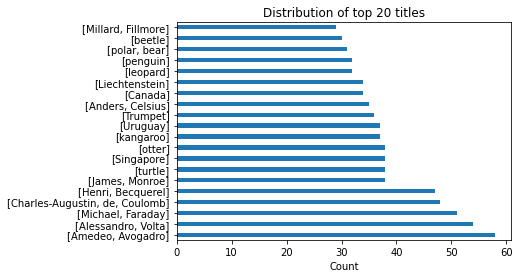

In [25]:
ax = df['ArticleTitle'].value_counts()[:20].plot(kind='barh', width= 0.4, title='Distribution of top 20 titles')
ax.set_xlabel("Count")

#### Difficulty from questioner
We can see that the questions are not evenly distributed by difficulty level. Around half of the questions are labelled as easy - category 1. The rest are evenly distributed between the medium and hard category - 2 and 3. 

Text(0, 0.5, 'Count')

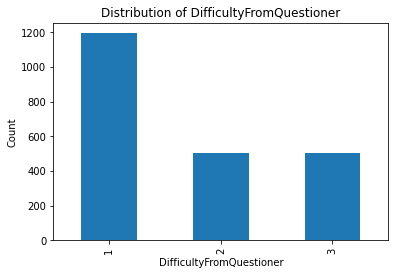

In [26]:
ax = df['DifficultyFromQuestioner'].value_counts().sort_index(ascending=True).plot(kind='bar', title='Distribution of DifficultyFromQuestioner')
ax.set_xlabel("DifficultyFromQuestioner")
ax.set_ylabel("Count")

#### Difficulty from answerer
We can see that the majority of the answers's difficulty level is easy - category 2. The too easy category 1 and too hard category 5 are the least present.  

Text(0, 0.5, 'Count')

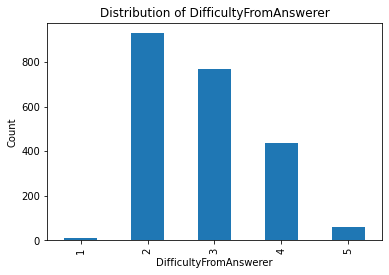

In [27]:
ax = df['DifficultyFromAnswerer'].value_counts().sort_index(ascending=True).plot(kind='bar', title='Distribution of DifficultyFromAnswerer')
ax.set_xlabel("DifficultyFromAnswerer")
ax.set_ylabel("Count")

#### DifficultyFromQuestioner and DifficultyFromAnswerer
Below we can see a grouped bar chart. The DifficultyFromQuestioner categories are broken down by DifficultyFromAnswerer categories. 

As expected, we can note the following things from the grouped bar plot
* In DifficultyFromAnswerer category 2 (easy), we can that the majority
of the questions are labelled with difficulty level 1 (easy).
* In DifficultyFromAnswerer category 3 (medium), we can see that the majority of the questions are labelled with difficulty level 2 (medium). 
* In DifficultyFromAnswerer category 4 (hard), we can see that the majority of the questions are labelled with difficulty level 3 (hard). 

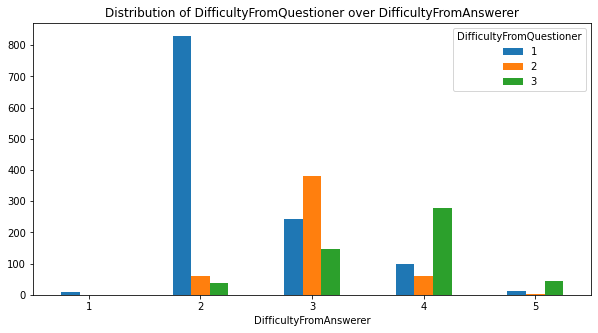

In [28]:
dfp = df.drop(columns=['ArticleTitle', 'Question', 'Answer'])

# pivot the data and aggregate
dfp = dfp.pivot_table(index='DifficultyFromAnswerer', columns='DifficultyFromQuestioner', values='DifficultyFromQuestioner', aggfunc='size')

# plot
dfp.plot(kind='bar', figsize=(10, 5), rot=0, title='Distribution of DifficultyFromQuestioner over DifficultyFromAnswerer')
plt.show()

# Clustering

## Vectorization

I use TF-IDF (Term Frequency-Inverse Document Frequency) to vectorize the questions. 

TF-IDF is a way of representing how important a particular term is in the context of a given document, based on how many times the term appears and how many other documents that same term appears in. The higher the TF-IDF, the more important that term is to that document.

In [29]:
punctuations = set(string.punctuation)
stop_words = STOP_WORDS
parser = English()

def spacy_tokenizer(sentence):
    """Tokenize, lowercase, and remove punctuation and English stop words."""
    tokens = parser(str(sentence))
    return [
        token.lower_.strip()
        for token in tokens
        if token.lower_.strip()
        and token.lower_ not in stop_words
        and token.text not in punctuations
        and not token.is_space
    ]


In [30]:
X = df['Question'] # the features we want to analyze

In [31]:
v = TfidfVectorizer(tokenizer=spacy_tokenizer, token_pattern=None)
X_tfidf = v.fit_transform(X)


## Topic modeling
Topic modeling is a method of discovering what types of topics exist within the question. Latent Dirichlet Allocation (LDA) is a particularly powerful technique that models topics as a distribution over words, and questions as a distribution over topics.

In [32]:
class colormap_size_func(object):
    def __init__(self, colormap, max_font_size):
        import matplotlib.pyplot as plt
        self.colormap = plt.cm.get_cmap(colormap)
        self.max_font_size = max_font_size

    def __call__(self, word, font_size, position, orientation,
                 random_state=None, **kwargs):
        if random_state is None:
            random_state = Random()
        r, g, b, _ = 255 * np.array(self.colormap(font_size / self.max_font_size))
        return "rgb({:.0f}, {:.0f}, {:.0f})".format(r, g, b)

/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


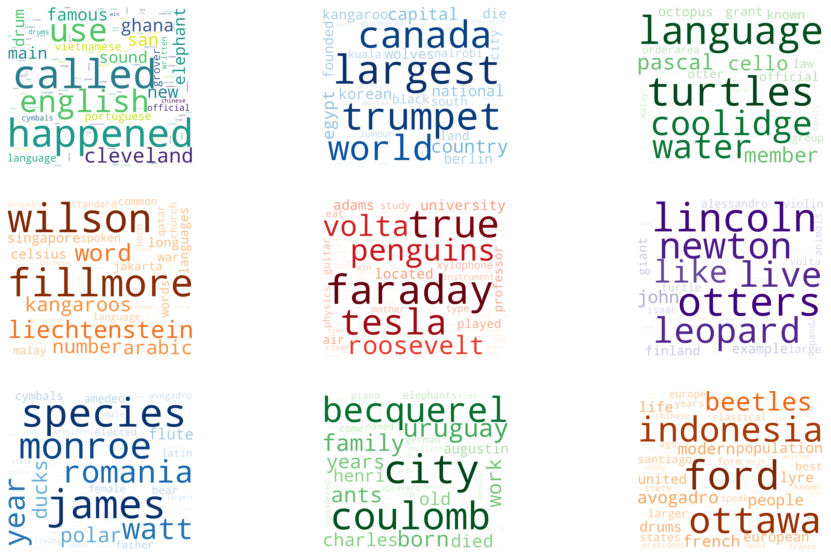

In [33]:
v = TfidfVectorizer(tokenizer=spacy_tokenizer, token_pattern=None, min_df=10, max_df=500)
X_vect = v.fit_transform(X)

# perform LDA and get the indices of top n_words_display words of each topic
n_topics = 9
n_words_display = 100
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
X_lda = lda.fit_transform(X_vect)
indices = (-lda.components_).argsort(axis=1)[:,:n_words_display]
vocab = np.array(v.get_feature_names_out())
# cmaps = ['YlOrBr', 'cool', 'bone_r', 'winter_r', 'spring_r', 'YlOrBr', 'cool', 'bone_r', 'winter_r']
cmaps = ['Purples', 'Blues', 'Greens', 'Oranges', 'Reds', 'Purples', 'Blues', 'Greens', 'Oranges']

# generate subplot axes
fig, axes = plt.subplots(3, 3, figsize=(16,10))
axes = axes.ravel()

for i in range(n_topics):
    if i == 0:
        color_func = None
    else:
        color_func = colormap_size_func(cmaps[i], 300)
    weights = lda.components_[i][indices[i]]
    words = vocab[indices[i,:]]
    dictionary = dict(zip(words, weights))
    wordcloud = WordCloud(background_color='white', height=1200, min_font_size=5,
                      width=1400, color_func=color_func,
                      max_words=n_words_display, relative_scaling=0.5,
                      max_font_size=300)
    wordcloud = wordcloud.generate_from_frequencies(dictionary)
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].axis('off')

## K means

In [34]:
km = KMeans(n_clusters=10, init='k-means++', n_init=10, random_state=42)
km.fit(X_tfidf)


KMeans(n_clusters=10)

In [35]:
clusters = km.predict(X_tfidf)
df['cluster'] = clusters

In [36]:
df.head()

,ArticleTitle,Question,Answer,DifficultyFromQuestioner,DifficultyFromAnswerer,cluster
0,"[Abraham, Lincoln]",Was Abraham Lincoln the sixteenth President of...,yes,1,2,4
2,"[Abraham, Lincoln]",Did Lincoln sign the National Banking Act of 1...,yes,1,3,0
4,"[Abraham, Lincoln]",Did his mother die of pneumonia?,no,1,3,0
6,"[Abraham, Lincoln]",How many long was Lincoln's formal education?,18 months,2,2,0
8,"[Abraham, Lincoln]",When did Lincoln begin his political career?,1832,2,2,0


In [37]:
# Number of questions in each cluster
df[['cluster', 'Question']].groupby(['cluster']).agg(['count'])

,Question
,count
cluster,
0,1682
1,63
2,37
3,40
4,214
5,68
6,28
7,30


In [38]:
# when creating word clouds, maps word fontsize to a color
class colormap_size_func(object):
    def __init__(self, colormap, max_font_size):
        import matplotlib.pyplot as plt
        self.colormap = plt.cm.get_cmap(colormap)
        self.max_font_size = max_font_size

    def __call__(self, word, font_size, position, orientation,
                 random_state=None, **kwargs):
        if random_state is None:
            random_state = Random()
        r, g, b, _ = 255 * np.array(self.colormap(font_size / self.max_font_size))
        return "rgb({:.0f}, {:.0f}, {:.0f})".format(r, g, b)

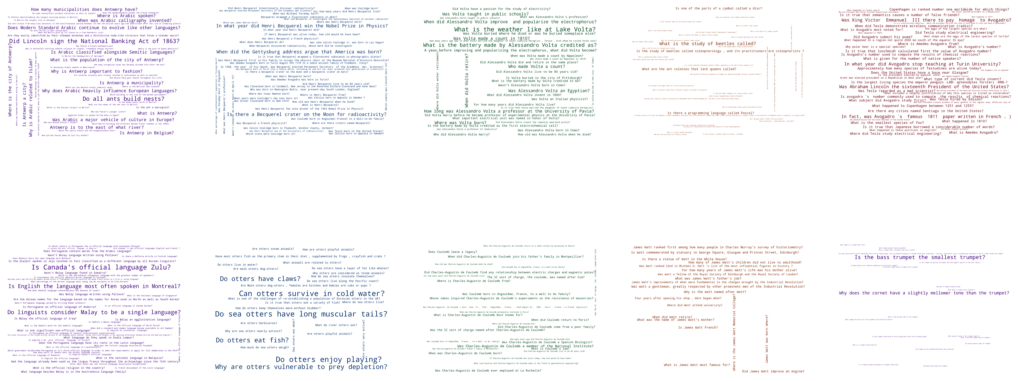

In [39]:
# generate subplot axes
fig, axes = plt.subplots(2, 5, figsize=(18,8))
axes = axes.ravel()

cmaps = ['Purples', 'Blues', 'Greens', 'Oranges', 'Reds', 'Purples', 'Blues', 'Greens', 'Oranges', 'Purples']

for i in range(10):
    color_func = colormap_size_func(cmaps[i], 10)
    temp_df = df[df['cluster']==i]
    freq_dict = temp_df['Question'].value_counts().to_dict()
    wordcloud = WordCloud(background_color='white', height=1800, min_font_size=2,
                      width=2400, color_func=color_func,
                      max_words=50)
    wordcloud = wordcloud.generate_from_frequencies(freq_dict)

    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].axis('off')

# How difficult is the Question?

In the next section I will build two binary classification models using Logistic Regression and Neural Networks. The model tries to classify each question as easy or not easy.

The target column is DifficultyFromQuestioner, which has three values: easy, medium, hard. The data is not evenly distributed between the three classes. To avoid losing data, I will merge the medium and hard questions into one group and label it as not easy questions. 


#### Train-test split
The first step is to merge the medium and hard DifficultyFromQuestioner categories into one class. With this step, I will have all the questions being evenly distributed between two classes
* easy, labelled as 0
* hard (or not easy), labelled as 1.

Next, I will split the data into train and test set - 70% of the data for training and 30% of the data for testing. 

In [40]:
classification_df = df[['Question', 'DifficultyFromQuestioner']].copy()
classification_df['DifficultyFromQuestioner'] = classification_df['DifficultyFromQuestioner'].replace(
    {1: 0, 2: 1, 3: 1}
)


In [41]:
classification_df = classification_df[['Question', 'DifficultyFromQuestioner']]


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  


In [42]:
# Count by class
df['DifficultyFromQuestioner'].value_counts()

0    1194
1    1009
Name: DifficultyFromQuestioner, dtype: int64

In [43]:
df.head()

,Question,DifficultyFromQuestioner
0,Was Abraham Lincoln the sixteenth President of...,0
2,Did Lincoln sign the National Banking Act of 1...,0
4,Did his mother die of pneumonia?,0
6,How many long was Lincoln's formal education?,1
8,When did Lincoln begin his political career?,1


In [44]:
classification_df.dtypes


Question                    object
DifficultyFromQuestioner    object
dtype: object

In [45]:
classification_df['DifficultyFromQuestioner'] = classification_df['DifficultyFromQuestioner'].astype(int)


In [46]:
classification_df.dtypes


Question                    object
DifficultyFromQuestioner     int64
dtype: object

In [47]:
X = classification_df['Question']
ylabels = classification_df['DifficultyFromQuestioner']

X_train, X_test, y_train, y_test = train_test_split(
    X, ylabels, test_size=0.3, random_state=72
)


## TF-IDF and Logistic Regression
I use TF-IDF (Term Frequency-Inverse Document Frequency) to vectorize the questions. 
The code is in section Clustering.

In [48]:
classifier = LogisticRegression(solver="lbfgs")

# Create pipeline using Bag of Words
pipe = Pipeline([('vectorizer', v),
                 ('classifier', classifier)])

# model generation
pipe.fit(X_train,y_train)

Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(max_df=500, min_df=10, stop_words='english',
                                 tokenizer=<function spacy_tokenizer at 0x7ff222860f80>)),
                ('classifier', LogisticRegression())])

In [49]:
# Predicting with a test dataset
y_pred = pipe.predict(X_test)

The original coursework run achieved approximately 0.54 test accuracy.

In [50]:
# Model Accuracy
print("test Accuracy:",metrics.accuracy_score(y_test, y_pred))

test Accuracy: 0.5446293494704992


In [51]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[268  88]
 [213  92]]
              precision    recall  f1-score   support

           0       0.56      0.75      0.64       356
           1       0.51      0.30      0.38       305

    accuracy                           0.54       661
   macro avg       0.53      0.53      0.51       661
weighted avg       0.54      0.54      0.52       661



## USE and XGBoost / Neural Network

### Universal Sentence Encoder
I will do the vectorization of the questions using universal sentence encoder (USE). I have decided to not apply any preprocessing steps, because of two reasons The first one is because USE does not require the text to be preprocessed. The second reason is because with the preprocessing steps we remove  context from the text and it can affect the USE. 

> This section downloads the Universal Sentence Encoder from TensorFlow Hub and therefore requires an internet connection on the first run.


In [52]:
use = hub.load("https://tfhub.dev/google/universal-sentence-encoder-large/5")

In [53]:
train_text = X_train.values
test_text = X_test.values
y_train = y_train.values

In [54]:
# Encoding questions into embedding vectors using universal sentence encoder

X_train = []
for r in tqdm(train_text):
  emb = use([r])
  text_emb = tf.reshape(emb, [-1]).numpy()
  X_train.append(text_emb)
X_train = np.array(X_train)

100%|██████████| 1542/1542 [01:38<00:00, 15.66it/s]


In [55]:
# Encoding questions into embedding vectors using universal sentence encoder

X_test = []
for r in tqdm(test_text):
  emb = use([r])
  text_emb = tf.reshape(emb, [-1]).numpy()
  X_test.append(text_emb)

X_test = np.array(X_test)

100%|██████████| 661/661 [00:39<00:00, 16.75it/s]


In [56]:
print ("X_train shape", X_train.shape)
print ("y_train shape", y_train.shape)
print ("X_test shape", X_test.shape)

X_train shape (1542, 512)
y_train shape (1542,)
X_test shape (661, 512)


### Keras Sequential Model

In [57]:
model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid'),
])


In [58]:
model.compile( 
    loss='binary_crossentropy', 
    optimizer=keras.optimizers.Adam(0.001),
    metrics=['accuracy']
)

In [59]:
history = model.fit(
    X_train, y_train, 
    epochs = 10, 
    batch_size = 512,
    validation_split = 0.1,
    verbose = 1,
    shuffle = True
)

Epoch 1/10
3/3 [==============================] - 1s 114ms/step - loss: 0.6867 - accuracy: 0.5523 - val_loss: 0.6695 - val_accuracy: 0.5419
Epoch 2/10
3/3 [==============================] - 0s 26ms/step - loss: 0.6634 - accuracy: 0.6128 - val_loss: 0.6398 - val_accuracy: 0.6774
Epoch 3/10
3/3 [==============================] - 0s 24ms/step - loss: 0.6343 - accuracy: 0.6929 - val_loss: 0.6009 - val_accuracy: 0.7806
Epoch 4/10
3/3 [==============================] - 0s 29ms/step - loss: 0.5987 - accuracy: 0.7657 - val_loss: 0.5525 - val_accuracy: 0.8387
Epoch 5/10
3/3 [==============================] - 0s 29ms/step - loss: 0.5556 - accuracy: 0.8075 - val_loss: 0.4979 - val_accuracy: 0.8194
Epoch 6/10
3/3 [==============================] - 0s 26ms/step - loss: 0.5064 - accuracy: 0.8320 - val_loss: 0.4417 - val_accuracy: 0.8452
Epoch 7/10
3/3 [==============================] - 0s 32ms/step - loss: 0.4591 - accuracy: 0.8342 - val_loss: 0.3930 - val_accuracy: 0.8645
Epoch 8/10
3/3 [==========

In [60]:
y_predictions = (model.predict(X_test) > 0.5).astype("int32")

The original coursework run achieved approximately 0.80 test accuracy.

In [61]:
# Model accuracy
model.evaluate(X_test, y_test)

21/21 [==============================] - 0s 2ms/step - loss: 0.4695 - accuracy: 0.7988


[0.46949872374534607, 0.7987897396087646]

### XGBoost
I use USE to vectorize the questions. 


In [62]:
# Initialize XGBoost using the original coursework hyperparameters.
model = XGBClassifier(
    max_depth=50,
    min_child_weight=1,
    n_estimators=200,
    n_jobs=-1,
    learning_rate=0.16,
    random_state=42,
    eval_metric='logloss',
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [63]:
print("test Accuracy:",metrics.accuracy_score(y_test, y_pred))

test Accuracy: 0.8245083207261724


In [64]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[300  56]
 [ 60 245]]
              precision    recall  f1-score   support

           0       0.83      0.84      0.84       356
           1       0.81      0.80      0.81       305

    accuracy                           0.82       661
   macro avg       0.82      0.82      0.82       661
weighted avg       0.82      0.82      0.82       661

